<a href="https://sigmoidal.ai/en/">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Feature Detection for 3D Reconstruction

**Author:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai/en/)

## Scope and reproducibility

This notebook uses `cv2.SIFT_create()` to extract SIFT keypoints and descriptors. The scale-space and Difference of Gaussians (DoG) cells are **instructional inspections** of the algorithm's principles; they are not a complete reimplementation of Lowe's SIFT.

The full implementation includes subpixel localization, histogram interpolation, and specific rules for assigning multiple orientations. Numerical results may vary with the OpenCV version and platform.

References: [Lowe (2004)](https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf) and the [COLMAP documentation](https://colmap.github.io/cli.html).

In [1]:
from pathlib import Path
import sys
from urllib.request import urlretrieve

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy
from PIL import Image
from scipy.ndimage import gaussian_filter

plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 11})

print(f"Python: {sys.version.split()[0]}")
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")

Python: 3.12.3
OpenCV: 4.11.0
NumPy: 1.26.4
SciPy: 1.17.1


## Load an image from the South Building dataset

The image is part of the [South Building dataset](https://colmap.github.io/datasets.html), published by the COLMAP project and credited to Christopher Zach. Cropping reduces the computational cost while preserving architectural texture for the analysis.

Original resolution: 3072 × 2304
Crop resolution: 800 × 700


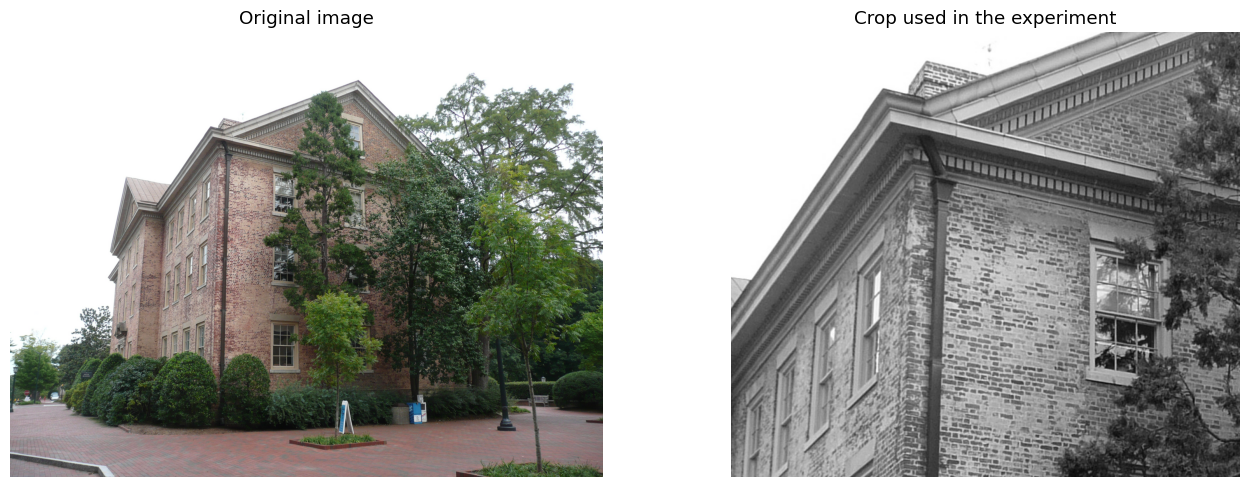

In [2]:
image_url = (
    "https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/"
    "feature-detection-3d-reconstruction/south_building_sample.jpg"
)
image_path = Path("south_building_sample.jpg")

if not image_path.exists():
    urlretrieve(image_url, image_path)

full_image = Image.open(image_path).convert("RGB")
crop_image = full_image.crop((800, 400, 1600, 1100))
image_rgb = np.asarray(crop_image)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

print(f"Original resolution: {full_image.width} × {full_image.height}")
print(f"Crop resolution: {image_gray.shape[1]} × {image_gray.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(full_image)
axes[0].set_title("Original image")
axes[1].imshow(image_gray, cmap="gray")
axes[1].set_title("Crop used in the experiment")
for axis in axes:
    axis.axis("off")
plt.tight_layout()

## Scale space and Difference of Gaussians

SIFT searches for structures at different scales. With three scale levels per octave, $k = 2^{1/3}$. DoG approximates the scale-normalized Laplacian of Gaussian and highlights local intensity changes.

First-octave sigmas: [1.6, 2.016, 2.54, 3.2, 4.032, 5.08]


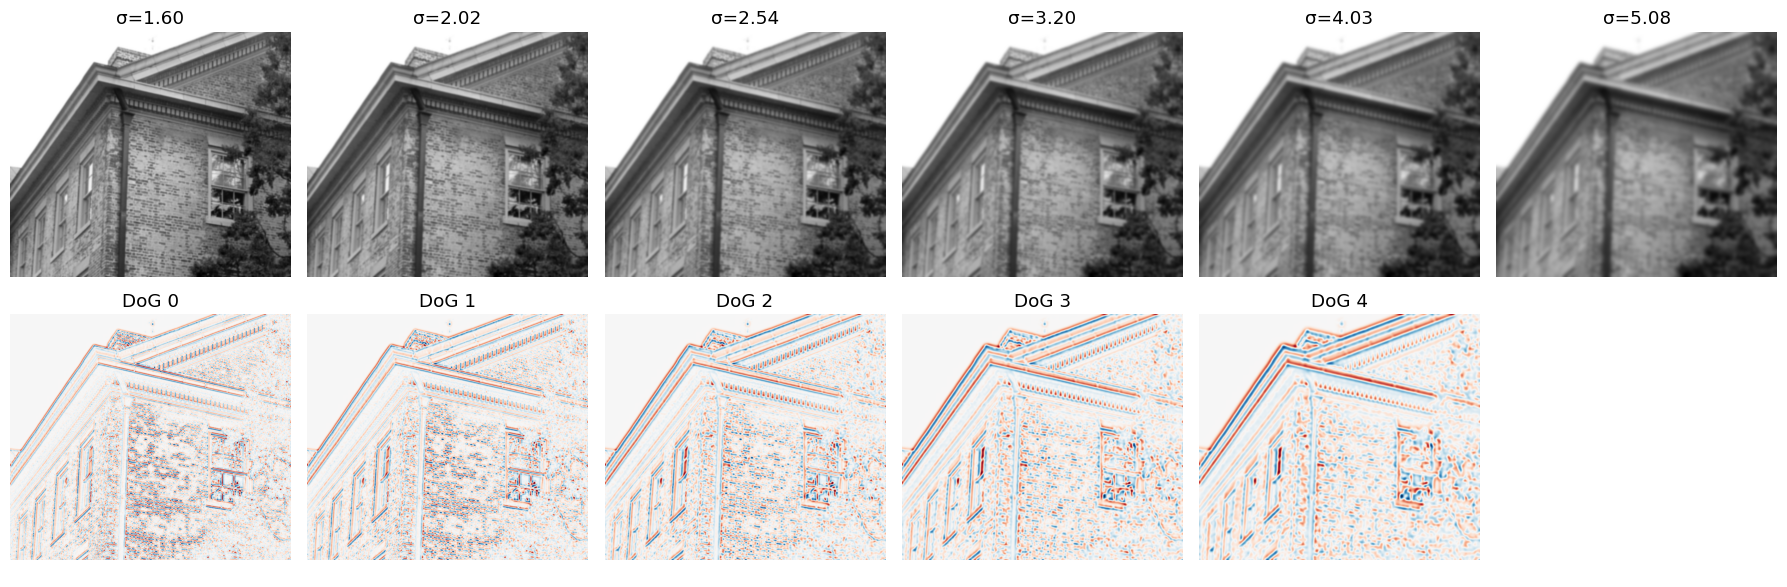

In [3]:
base_sigma = 1.6
levels_per_octave = 3
k = 2 ** (1 / levels_per_octave)
sigmas = [base_sigma * (k ** index) for index in range(levels_per_octave + 3)]
scale_space = [
    gaussian_filter(image_gray.astype(np.float64) / 255, sigma=sigma)
    for sigma in sigmas
]
dog = [scale_space[index + 1] - scale_space[index] for index in range(len(scale_space) - 1)]

print("First-octave sigmas:", [round(sigma, 3) for sigma in sigmas])
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for index, (image, sigma) in enumerate(zip(scale_space, sigmas)):
    axes[0, index].imshow(image, cmap="gray")
    axes[0, index].set_title(f"σ={sigma:.2f}")
    axes[0, index].axis("off")
for index, image in enumerate(dog):
    axes[1, index].imshow(image, cmap="RdBu", vmin=-0.05, vmax=0.05)
    axes[1, index].set_title(f"DoG {index}")
    axes[1, index].axis("off")
axes[1, -1].axis("off")
plt.tight_layout()

## Extract keypoints and descriptors with SIFT

Each keypoint records a position, scale, and orientation. Each SIFT descriptor has 128 components and summarizes the local distribution of gradient orientations.

Detected keypoints: 10,982
Descriptor shape: (10982, 128)
Numeric type: float32


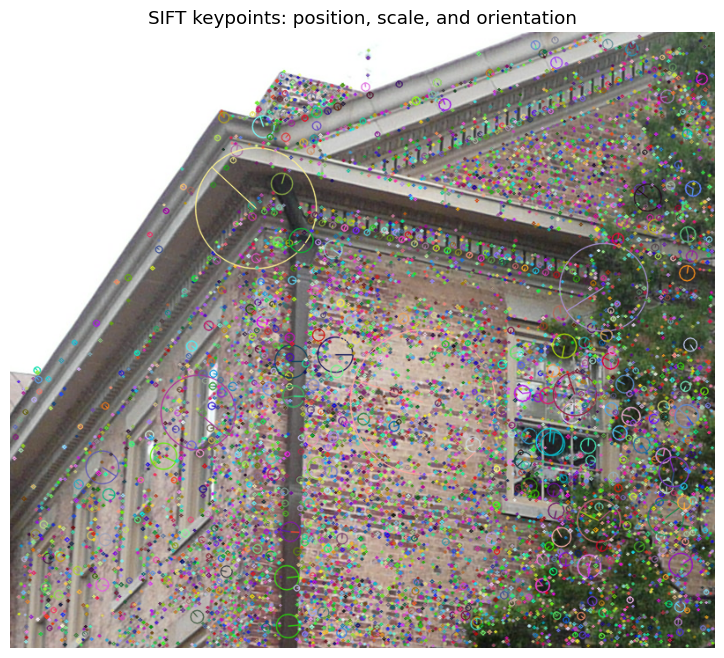

In [4]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(image_gray, None)

print(f"Detected keypoints: {len(keypoints):,}")
print(f"Descriptor shape: {descriptors.shape}")
print(f"Numeric type: {descriptors.dtype}")

keypoint_image = cv2.drawKeypoints(
    image_rgb, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
plt.figure(figsize=(12, 8))
plt.imshow(keypoint_image)
plt.title("SIFT keypoints: position, scale, and orientation")
plt.axis("off")
plt.show()

## How texture affects feature availability

The number of keypoints does not measure reconstruction quality in isolation. It indicates where candidate correspondences exist. To avoid an area imbalance, this experiment compares the upper and lower thirds of the crop, two bands with equal dimensions. In SfM, descriptor matches must still pass geometric verification before they can contribute to 3D points.

Keypoints in the upper third: 2,023
Keypoints in the lower third: 4,579
Lower/upper ratio: 2.26×


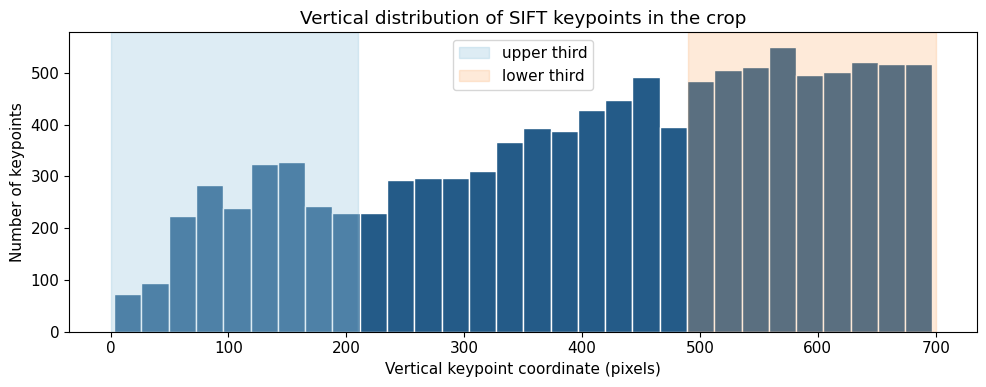

In [5]:
y_coordinates = np.array([point.pt[1] for point in keypoints])
height = image_gray.shape[0]
upper_third = y_coordinates < 0.30 * height
lower_third = y_coordinates >= 0.70 * height

print(f"Keypoints in the upper third: {upper_third.sum():,}")
print(f"Keypoints in the lower third: {lower_third.sum():,}")
print(f"Lower/upper ratio: {lower_third.sum() / upper_third.sum():.2f}×")

plt.figure(figsize=(10, 4))
plt.hist(y_coordinates, bins=30, color="#245b88", edgecolor="white")
plt.axvspan(0, 0.30 * height, color="#9ecae1", alpha=0.35, label="upper third")
plt.axvspan(0.70 * height, height, color="#fdae6b", alpha=0.25, label="lower third")
plt.xlabel("Vertical keypoint coordinate (pixels)")
plt.ylabel("Number of keypoints")
plt.title("Vertical distribution of SIFT keypoints in the crop")
plt.legend()
plt.tight_layout()

## Summary

- Scale space makes it possible to search for local structures at different sizes.
- SIFT represents each point with a position, scale, orientation, and 128-dimensional descriptor.
- Textured regions tend to provide more candidate correspondences than homogeneous areas.
- In 3D reconstruction, descriptor matching and geometric verification are the next stages.